In [34]:
# Import packages
import numpy as np
import pandas as pd
import hdbscan
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split



In [35]:
# Create functions

def remove_non_numbers(data):
    """Remove colums with data which are not numbers and return the matrix, without the columns, and the indexes of the removed rows."""
    del_data = data.copy()
    del_idx = {}

    # Removing all non int or float type features looping from the end.
    iterate = len(del_data[0,:])-1
    for i in range(iterate+1):
        if type(del_data[0,iterate-i]) != float and type(del_data[0,iterate-i]) != int:
            # print(iterate-i, type(del_data[0,iterate-i]), data[0,iterate-i])
            del_data = np.delete(del_data, obj=iterate-i, axis=1)
            del_idx[iterate-i] = iterate-i
    """
    for i in range(len(del_data[0,:])):
        print(i, type(del_data[0,i]), del_data[0,i])

    for i in range(len(data[0,:])):
    print(i, type(data[0,i]), data[0,i])
        """
    return del_data, del_idx


def normalize_feature(feature):
    """Min-max normalization."""
    # This retains the relative position of the data points.
    return (feature-np.min(feature)) / (np.max(feature)-np.min(feature))

def normalize(data, axis=1):
    """Using the normalize_feature function on an np.array along a chosen axis."""
    norm_data = np.zeros_like(data)
    for i in range(data.shape[axis]):
        norm_data[:,i] = normalize_feature(data[:,i])
    return norm_data

def clustering(data, cluster_size=10, min_samples=10, distance_type='euclidean'):
    """Takes data, minimum cluster size, distance metric and returns an array of the data with an added column at index 0 with the cluster label and the number of clusters."""
    clusterer = hdbscan.HDBSCAN(min_cluster_size=cluster_size, min_samples=min_samples, metric=distance_type)
    clusterer.fit(data)
    return clusterer.labels_.max()+1 , np.insert(data, 0, clusterer.labels_.flatten(), axis=1)

def center_of_mass(number_of_clusters, clusters):
    """Takes a number of clusters and a matrix with points declaring where the first column references which cluster to which the point belongs and
    the rest the coordinates of the point."""
    cluster_centers = np.zeros((number_of_clusters, len(clusters[0])))
    balancing_vector = np.zeros_like(cluster_centers)
    clusters[:,0] += 1
    for i in range(len(clusters[:,None])):
        if clusters[i,0] > 0:
            cluster_centers[int(clusters[i,0])-1] += clusters[i]
            balancing_vector[int(clusters[i,0])-1] += 1 # Keeps track of how many points are in each cluster.
    return cluster_centers / balancing_vector




def reduce_dimension(vector,clusters):
    """Takes a vector and a set of clusters and reduces the vectors dimension to the number of clusters using the clusters as a basis."""
    # Vector projection
    transformation_matrix = np.zeros([len(clusters), len(vector)])

    for i in clusters:
        transformation_matrix[i] = center_of_mass(clusters[i])

    reduced_vector = transformation_matrix * vector
    return reduced_vector

def get_cmap(n, name='hsv'):
    '''Returns a function that maps each index in 0, 1, ..., n-1 to a distinct 
    RGB color; the keyword argument name must be a standard mpl colormap name.'''
    return plt.cm.get_cmap(name, n)

def show_clusters(sorted_clusters, number_of_clusters, centers_of_mass, clusterspan):
    """Creates a 3D plot of the clusters and their center of mass."""
    
    %matplotlib widget

    fig = plt.figure(figsize = (10,10))
    ax = plt.axes(projection='3d')
    ax.grid()

    cmap = get_cmap((number_of_clusters+1)*2)

    for i in range(1,number_of_clusters+1):
        x1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), 1]
        y1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), 2]
        z1 = sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), 3]
        ax.scatter(x1, y1, z1, c = cmap(i), s = 100)
        xc1,yc1,zc1 = centers_of_mass[i-1, 1:4]
        print(i, xc1, yc1, zc1)
        ax.scatter(xc1,yc1,zc1, c = cmap(-i), s = 100)

    # xc2,yc2,zc2 = centers_of_mass[1, 1:4]

    # print("1", xc1, yc1, zc1)
    # print("2", xc2, yc2, zc2)

    ax.set_title('3D Scatter Plot')

    # Set axes label
    ax.set_xlabel('x', labelpad=20)
    ax.set_ylabel('y', labelpad=20)
    ax.set_zlabel('z', labelpad=20)

def compare_Euclidean(reference, comparables, k=3):
    """Takes a reference point and a matrix of comparable points and returns the first column of the comparable points (ID) and
    the Euclidean distances sorted by distance from low to high."""
    # abs_compare = np.abs(comparables[:,1:] - reference[1:])
    sq_compare = np.square(comparables[:,1:] - reference[1:])
    # print("sq_compare", sq_compare)
    sum_compare = np.sum(sq_compare, axis=1)
    # print("sum_compare", sum_compare)
    Euc_compare = np.sqrt(sum_compare)
    # print("Euc_compare", Euc_compare)

    # np.insert(Euc_compare, 0, comparables[:, 0].flatten())  # Insert IDs back
    # print(comparables[:, 0], Euc_compare)
    Euc_compare = np.vstack((comparables[:, 0], Euc_compare)).T
    # print("Euc_compare", Euc_compare)

    sorted_dis = Euc_compare[Euc_compare[:, 1].argsort()]   # Sort Euc_compare

    return sorted_dis[0:k, :]

    

# Outline
1. Find Clusters using hdbscan.
2. Find the centers of the clusters.
3. Reduce the dimensionality to the number of clusters and create a new vector space.
4. Find a suitable model for finding comparisons.

## TODO
1. Linear regression.
2. Neural network.
3. Prepare data (choose features)

# Change to np.array and choose features

Start with excluding the feature that are not int or float.
Later give the unused features numerical values and implement them as well.


In [36]:
blobs, blobs_labels, blob_centers = sklearn.datasets.make_blobs(n_samples=1000, n_features=3, centers=20, return_centers=True)
print(blobs)

[[10.67804353  8.10751219 -3.40182634]
 [ 7.33490141  0.37859697  7.32295851]
 [-7.0266697  -9.08971195 -7.46665009]
 ...
 [ 2.89113463  5.51148443  7.90546765]
 [ 6.54011974 -2.00734211  9.42223751]
 [ 1.92908261 -1.61367391 -9.09449619]]


# Clustering

In [40]:
def create_clusterspan(sorted_clusters):
    clusterspan = np.zeros(number_of_clusters + 1)

    j = 0
    for i in range(len(sorted_clusters[:,0])-1):
        if sorted_clusters[i, 0] < sorted_clusters[i+1,0]:
            # print(sorted_clusters[i, 0])
            clusterspan[j+1] = i+1
            j += 1
    clusterspan[-1] = len(sorted_clusters[:,0])
    return clusterspan

data = blobs

# Normalizing the data
norm_data = normalize(data)

# Clustering
number_of_clusters, clustered_data = clustering(norm_data, min_samples=2, cluster_size=4)

sorted_clusters = clustered_data[clustered_data[:, 0].argsort()] # sorting the clustered data by cluster affiliation
sorted_clusters[:,0] +=1

clusterspan = create_clusterspan(sorted_clusters)

print(sorted_clusters, number_of_clusters, clusterspan)

[[ 0.          0.75475837  0.62992215  0.8970529 ]
 [ 0.          0.45464724  0.82878712  0.87806726]
 [ 0.          0.69657288  0.76049746  0.82017781]
 ...
 [16.          0.63321324  0.85826726  0.8635581 ]
 [16.          0.54863325  0.77871126  0.84430767]
 [16.          0.58519385  0.82772923  0.89537949]] 16 [   0.   25.   75.  125.  175.  325.  375.  425.  475.  525.  575.  625.
  671.  718.  768.  916. 1000.]


/opt/anaconda3/envs/Machine_Learning/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/Machine_Learning/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


# Finding center-of-mass

blob [[ 2.49456152 -2.1890493  -9.6730232 ]
 [-0.13897675 -4.80534423  3.84435339]
 [ 8.82582887 -1.43228022  8.82432932]
 [ 7.4516554  -0.96232168  6.45014348]
 [-8.09062978  8.96477234  2.83540674]
 [-9.58550141 -6.61390926 -6.36030522]
 [ 3.62458725  2.49041292  8.576597  ]
 [ 8.81075624 -8.66405079  6.83306935]
 [ 9.87104203 -4.70824622  0.50585294]
 [ 5.03888333 -4.17735148  8.21459574]
 [ 8.57449752 -3.31233119 -4.61901561]
 [ 6.81561658  9.01518438  6.05799965]
 [ 5.56383703  7.12314845 -9.39959141]
 [ 9.71243748  8.61764185 -2.52434246]
 [-6.35055817 -9.2817891  -6.00148012]
 [-9.12179068  6.74110405 -9.84330537]
 [ 2.03757577  6.57210144  9.13159463]
 [ 9.61971499  3.49173968  1.78784189]
 [-0.9108574  -9.19415619 -3.91438638]
 [-9.59315286 -1.69232326  2.05547328]] not blob [[ 1.         -9.04787892  6.58384764 -9.65914642]
 [ 2.         -7.97427937  9.03565291  2.64509765]
 [ 3.         -9.76127529 -1.96136241  2.10206044]
 [ 4.         -5.76998374 -8.26446759 -5.54758052]
 

/opt/anaconda3/envs/Machine_Learning/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/Machine_Learning/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_50234/3638686061.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return plt.cm.get_cmap(name, n)
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_50234/3638686061.py:89: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedenc

IndexError: index 17 is out of bounds for axis 0 with size 17

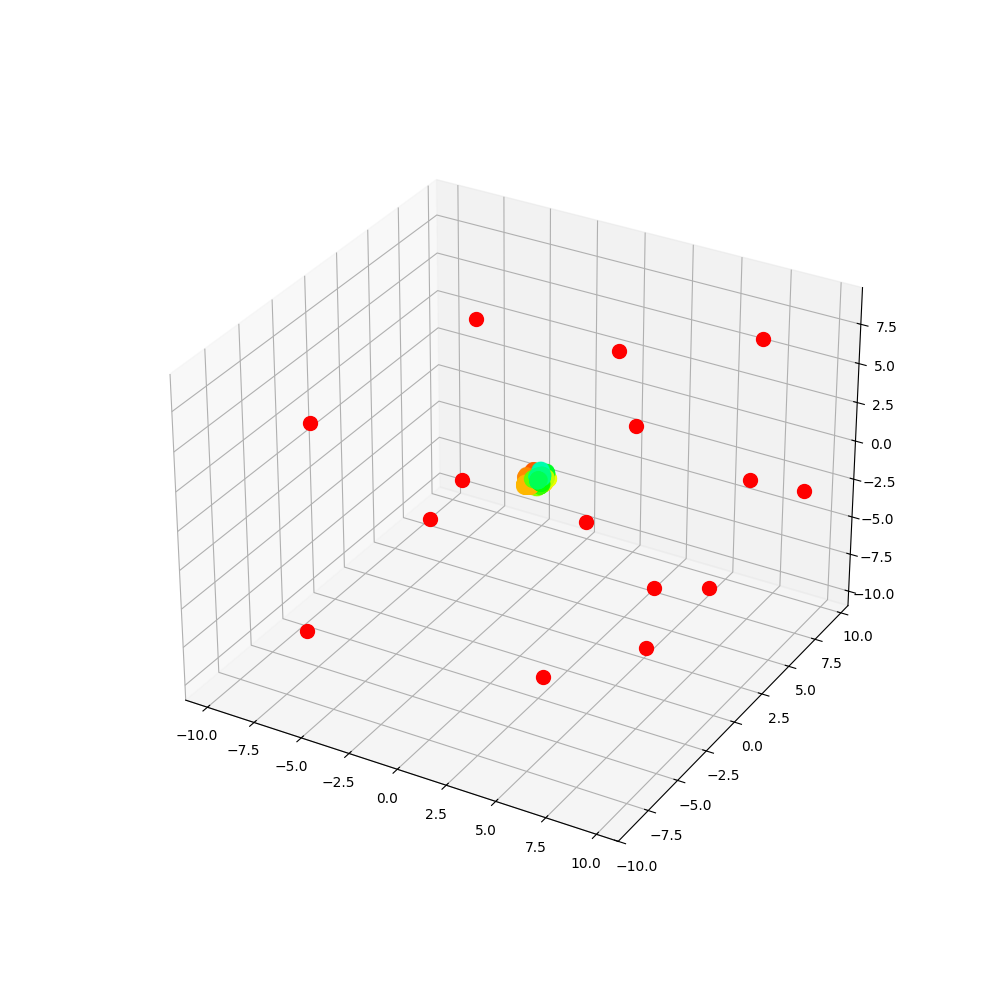

In [44]:
number_of_clusters_blobs, clustered_blobs = clustering(blobs, min_samples=2, cluster_size=4)
centers_of_mass = center_of_mass(number_of_clusters_blobs, clustered_blobs.copy())
# norm_blob_centers = normalize(blob_centers)
print('blob', blob_centers, 'not blob', centers_of_mass)
show_clusters(sorted_clusters, number_of_clusters, centers_of_mass, clusterspan)

blob [[6.21023086e-01 3.87645520e-01 8.97407453e-03]
 [4.85721406e-01 2.44654936e-01 7.21356042e-01]
 [9.46300725e-01 4.29005862e-01 9.83806749e-01]
 [8.75700657e-01 4.54690904e-01 8.58684307e-01]
 [7.71942065e-02 9.97244788e-01 6.68183343e-01]
 [3.93103796e-04 1.45809898e-01 1.83558287e-01]
 [6.79079725e-01 6.43396135e-01 9.70750959e-01]
 [9.45526347e-01 3.37617753e-02 8.78864959e-01]
 [1.00000000e+00 2.49961716e-01 5.45413062e-01]
 [7.51741147e-01 2.78977156e-01 9.51673058e-01]
 [9.33388228e-01 3.26253843e-01 2.75326339e-01]
 [8.43023281e-01 1.00000000e+00 8.38017856e-01]
 [7.78711371e-01 8.96592957e-01 2.33842580e-02]
 [9.91851471e-01 9.78272772e-01 3.85718128e-01]
 [1.66592798e-01 0.00000000e+00 2.02468801e-01]
 [2.42168855e-02 8.75712760e-01 0.00000000e+00]
 [5.97544810e-01 8.66476118e-01 1.00000000e+00]
 [9.87087725e-01 6.98122495e-01 6.12975418e-01]
 [4.46064967e-01 4.78947570e-03 3.12461146e-01]
 [0.00000000e+00 4.14793509e-01 6.27079913e-01]] not blob [[ 1.          0.14554852

/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_50234/3638686061.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return plt.cm.get_cmap(name, n)
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_50234/3638686061.py:89: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x1, y1, z1, c = cmap(i), s = 100)
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_50234/3638686061.py:92: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping w

IndexError: index 17 is out of bounds for axis 0 with size 17

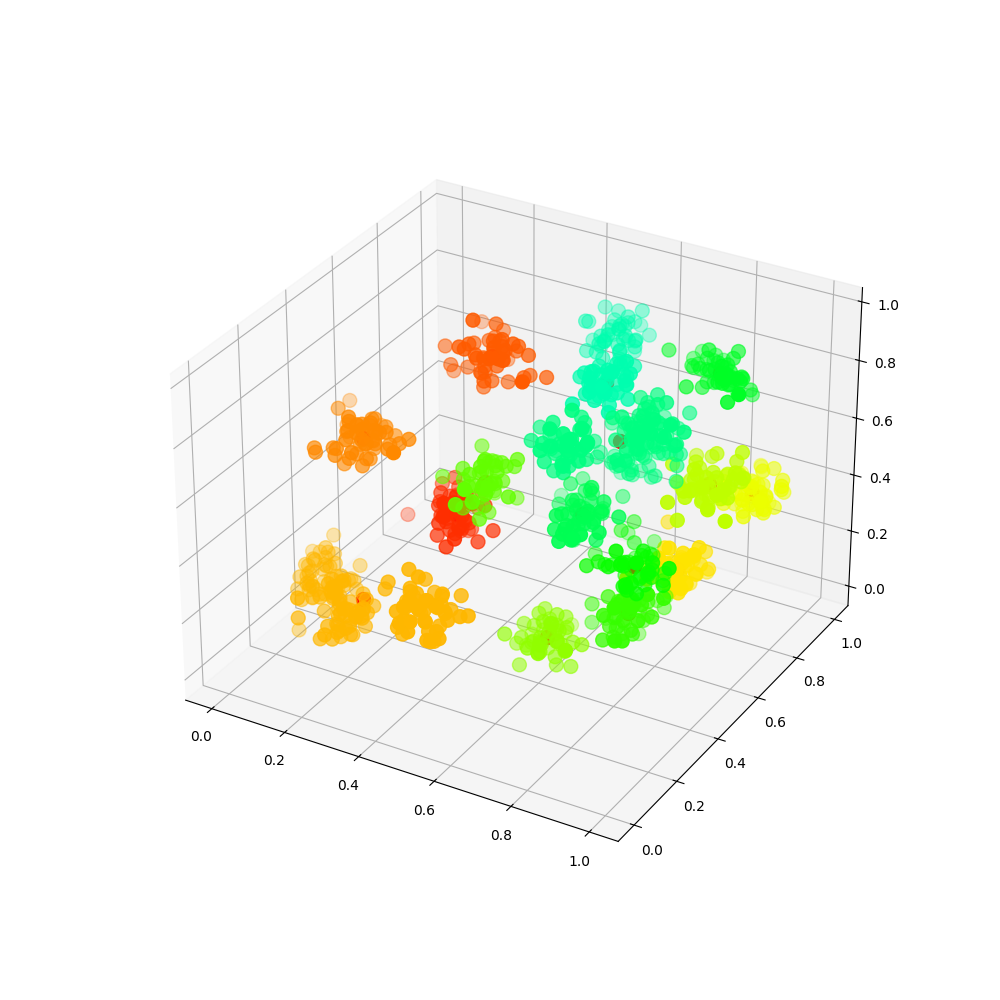

In [41]:
centers_of_mass = center_of_mass(number_of_clusters, clustered_data.copy())
norm_blob_centers = normalize(blob_centers)
print('blob', norm_blob_centers, 'not blob', centers_of_mass)
show_clusters(sorted_clusters, number_of_clusters, centers_of_mass, clusterspan)

In [14]:
CoM = np.delete(centers_of_mass, 0, axis=0)
print(CoM)
x = compare_Euclidean(sorted_clusters[0,:], CoM, np.shape(CoM)[0])

print(x)

[[2.         0.82133111 0.40895409 0.21031746]
 [3.         0.08347132 0.2708457  0.22344925]
 [4.         0.51984832 0.09743124 0.20913462]]
[[4.         0.35722684]
 [2.         0.52308891]
 [3.         0.6119822 ]]


# Finding minimal cluster size

In [11]:
# Improved Silhouette method

def cluster_silhouette(clusterdata, CS, cluster_index, CoM):
    # print(CS, CS[cluster_index], CS[cluster_index+1])
    current_cluster = clusterdata[int(CS[cluster_index]):int(CS[cluster_index+1]), :]
    other_clusters = np.delete(CoM, cluster_index-1, axis=0)
    # nearest_cluster_index = compare_Euclidean(ref_point, other_clusters, np.shape(other_clusters)[0])[0, 0]

    n = np.shape(current_cluster)[0] # Data points in current cluster
    if n<2:
        return 0.0
    dis_cur_cluster = 0
    NoOC = np.shape(other_clusters)[0] # NoOC = number of other clusters
    dis_cluster = np.zeros(NoOC)
    dis_near_cluster = 0.0

    # print("NoOC",NoOC)
    for j in range(0, n):
        
        ref_point = current_cluster[j, :]
        # print(j, ref_point)
        dis_cur_cluster += np.sum(compare_Euclidean(ref_point, current_cluster)[:, 1]) / n
        
        for l in range(0, NoOC):
            # nearest_cluster_index = int(compare_Euclidean(ref_point, other_clusters, np.shape(other_clusters)[0])[0, 0])
            nearest_cluster = clusterdata[int(CS[l]):int(CS[l+1]), :]
            m = np.shape(nearest_cluster)[0] # Data points in nearest cluster
            # print("m", m)
            dis_cluster[l] = np.sum(compare_Euclidean(ref_point, nearest_cluster)[:, 1]) / m
            # print("j", j, "l",l)
        # print("min", np.min(dis_cluster, axis=0))
        dis_near_cluster += np.min(dis_cluster, axis=0)
        
    # print("near:", dis_near_cluster, "cur:", dis_cur_cluster) #, "diff:", dis_near_cluster-dis_cur_cluster, "frac:", dis_near_cluster-dis_cur_cluster / dis_near_cluster)
    average_silhouette = (dis_near_cluster - dis_cur_cluster) / np.maximum(dis_near_cluster, dis_cur_cluster)
    # print("max", np.maximum(dis_near_cluster, dis_cur_cluster))
    # print("average silhouette", average_silhouette)
    return average_silhouette

def Silhouette(SC, NoC, CoM, CS):
    # SC = sorted clusters, NoC = number of clusters, CoM = centers of mass, CS = clusterspan
    

    average_silhouette_clusters = np.zeros((NoC, 2))

    # Find nearest cluster
    # CS = np.delete(CS, 0)
    for i in range(1, NoC):
        # print(i)
        average_silhouette_clusters[i-1, :] = i, cluster_silhouette(SC, CS, i, CoM)
        
    # print(average_silhouette_clusters)

    
    average_overall_silhouette = np.sum(average_silhouette_clusters[:, 1]) / NoC
    return average_overall_silhouette

silhouette = Silhouette(sorted_clusters, number_of_clusters, centers_of_mass, clusterspan)
print(silhouette, number_of_clusters)

0.01744243051278492 50


In [ ]:
# Elbow method using WCSS

def WCSS(cluster, center):
    squares = np.square(cluster-center)
    SS = np.sum(squares, axis=1)
    WCSS = np.sum(SS, axis=0) / np.shape(cluster)[0]
    return WCSS

WCSS_array = np.zeros(number_of_clusters)

for i in range(0,number_of_clusters):
        WCSS_array[i] = WCSS(sorted_clusters[int(clusterspan[i]):int(clusterspan[i+1]), :], centers_of_mass[i])

print(WCSS_array)


[1.17426737 1.24698258 1.57447655 1.23453494]


/opt/anaconda3/envs/Machine_Learning/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/Machine_Learning/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_32655/715646196.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  return plt.cm.get_cmap(name, n)
/var/folders/s9/fpc42dw53pgc33tc9cwdpsbh0000gp/T/ipykernel_32655/715646196.py:99: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence 

[[  0.          57.73943666  14.12217556 128.        ]
 [  0.          57.75076219  18.62561078  92.        ]
 [  0.          57.42930805  14.09352221  92.        ]
 [  0.          57.66601141  18.42416965   2.        ]
 [  0.          58.39627115  15.08801677  96.        ]
 [  0.          56.83508407  13.97477716  28.        ]
 [  0.          56.8557736   16.7292357   29.        ]
 [  0.          57.95541683  19.22483659  25.        ]
 [  0.          58.72915215  15.55824031  31.        ]
 [  0.          56.99382914  13.76395693  92.        ]
 [  0.          57.03872123  14.51837914 101.        ]
 [  0.          58.25900661  15.69232137  92.        ]
 [  0.          58.65181654  16.0214216   12.        ]
 [  0.          57.50456805  18.43661352 104.        ]
 [  0.          58.66651782  16.32737215  13.        ]
 [  0.          56.1699989   15.46807348 201.        ]
 [  0.          56.57098423  13.91934301  34.        ]
 [  0.          56.96126794  16.37289757  91.        ]
 [  0.    

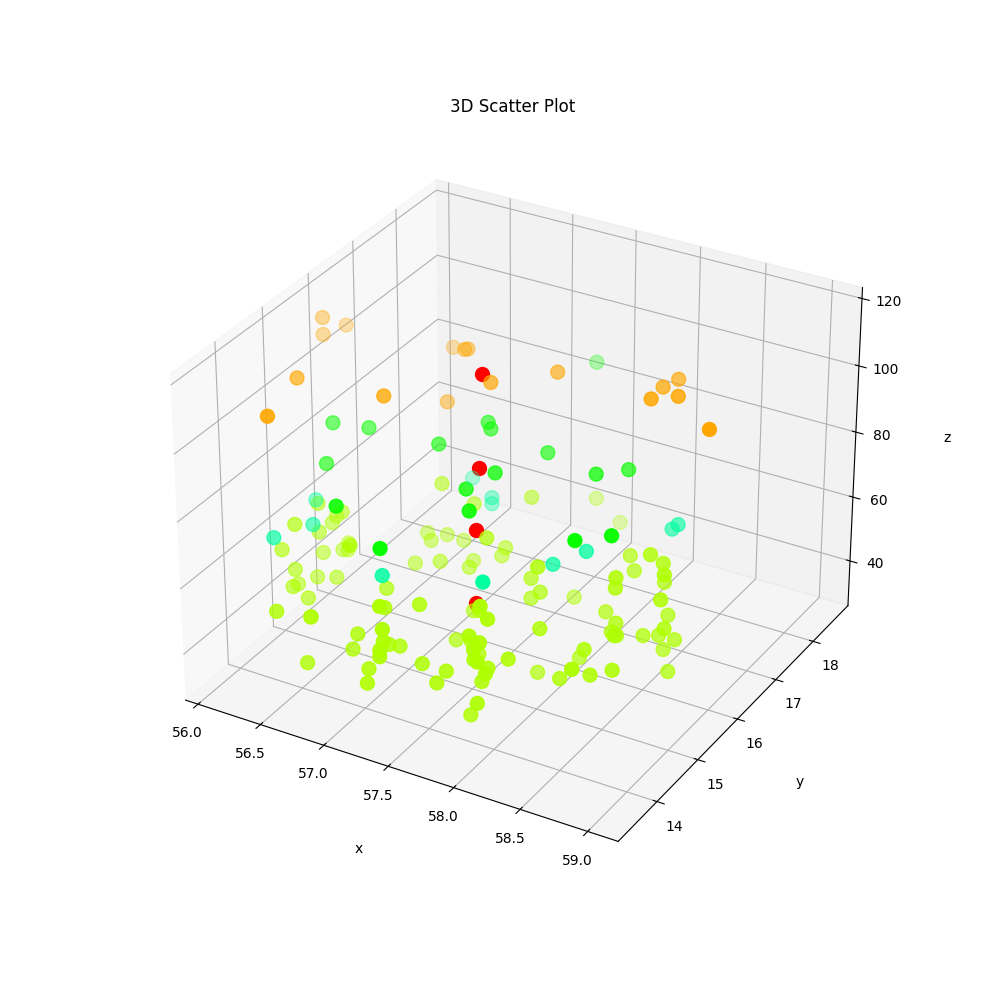

In [ ]:
# Clustering
number_of_clusters, clustered_data = clustering(data)

sorted_clusters = clustered_data[clustered_data[:, 0].argsort()] # sorting the clustered data by cluster affiliation
sorted_clusters[:,0] +=1
print(sorted_clusters, number_of_clusters)

centers_of_mass = center_of_mass(number_of_clusters, clustered_data.copy())
show_clusters(sorted_clusters, number_of_clusters, centers_of_mass, clusterspan)

In [13]:
def vector_norm(vector):
    return np.sqrt(vector @ vector.T)

def create_unit_vector(vector):
    """Takes a vector and creates a unit vector in the same direction."""
    unit_vector = vector / vector_norm(vector)
    return unit_vector

def create_basis(centers_of_mass):
    """Takes the centers_of_mass array and outputs a transformation matrix."""
    basis = np.zeros_like(centers_of_mass[:, 1:])
    for i in range(len(centers_of_mass[:, None])):
        basis[i] = create_unit_vector(centers_of_mass[i, 1:])

    return basis

transformation_matrix = create_basis(centers_of_mass)

"""
print(np.shape(transformation_matrix@norm_data.T))
print(centers_of_mass)
print(transformation_matrix)
print(transformation_matrix[1,:]@transformation_matrix[1,:].T)
print(transformation_matrix@norm_data.T)
"""

embedded_data = (transformation_matrix@norm_data.T).T

norm_embedded_data = normalize(embedded_data)

# print(embedded_data)
# print(np.shape(embedded_data))
print(norm_embedded_data, np.shape(norm_embedded_data))

[[0.31171598 0.22697339 0.20167845 ... 0.18507538 0.21943158 0.21635907]
 [0.35763993 0.08032877 0.2193862  ... 0.21612698 0.45272962 0.29731637]
 [0.40726519 0.31592384 0.35686036 ... 0.31750825 0.37032879 0.48949635]
 ...
 [0.31728607 0.36744372 0.38739885 ... 0.30830064 0.57111377 0.3829223 ]
 [0.34868582 0.33409693 0.36794611 ... 0.30496062 0.4636439  0.36021988]
 [0.31990081 0.21630009 0.20201402 ... 0.185708   0.23790846 0.23883388]] (1000, 50)


In [ ]:
class LinearRegression:
    def __init__(self, learning_rate=0.01, iterations=100):
        self.lr = learning_rate
        # self.iterations = iterations

    def fit(self, Data, Targets):
        n_samples, n_features = Data.shape
        self.weight = np.zeros(n_features) # np.random.random((np.shape(Data[0,:])))
        self.bias = 0
        self.iterations = n_samples

        for _ in range(self.iterations):
            predict = np.dot(Data, self.weight) + self.bias
            dw = 1/n_samples * np.dot(Data.T, predict-Targets)
            db = 1/n_samples * np.sum(predict - Targets)

            self.weight -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, testing_data):
        y_predict = np.dot(testing_data, self.weight) + self.bias
        return y_predict
    
    def mean_abs_e(self, y_true, y_pred):
        error = np.mean(np.abs(y_true - y_pred))
        return error
    
    def mse(self, y_true, y_pred):
        error = np.mean((y_true-y_pred)**2)
        return error
    
Targets = training_data[0:data_points, 5]
norm_Targets = normalize_feature(Targets)

samples = np.shape(norm_embedded_data)[0]

train_data, testing_data = train_test_split(norm_embedded_data, test_size=0.20)
# print("train data", train_data)
train_targets, testing_targets = train_test_split(norm_Targets, test_size=0.20)

regression = LinearRegression()
regression.fit(train_data, train_targets)
prediction = regression.predict(testing_data)

mse = regression.mse(testing_targets, prediction)

absolute = regression.mean_abs_e(testing_targets, prediction)

print(mse, absolute)


0.007258542990596796 0.03585238365402181


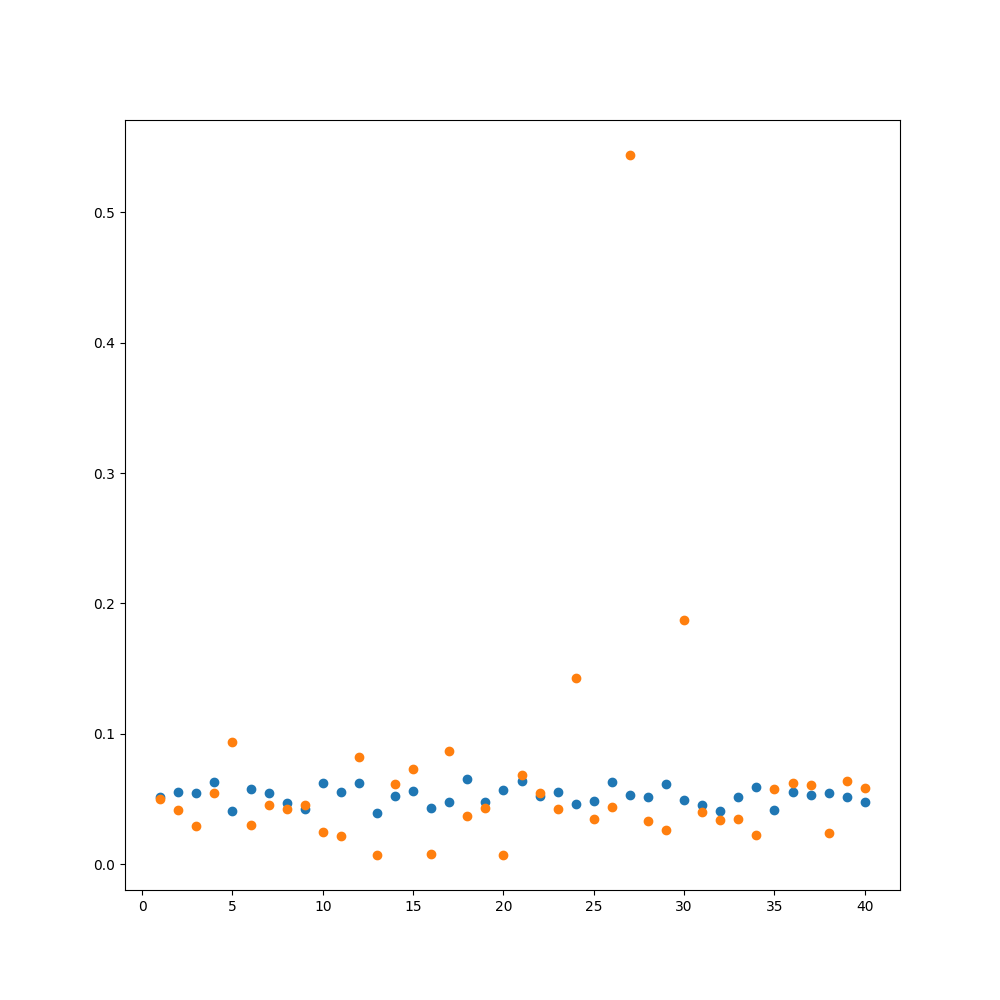

In [ ]:
# Visualize
fig, ax = plt.subplots(figsize=(10, 10))

x = np.linspace(1,len(prediction), len(prediction))
ax.scatter(x, prediction)
ax.scatter(x, testing_targets)


# Finding comparable data

In [ ]:
def k_closest_points(reference, comparables, k=3):
    """k must be larger than 1."""
    # reference = reference point in the form of an array with ID and Sale price (1 x 2)
    # comparables = the collection of all points in the form of an array with ID and Sale price (n x 2)
    
    closest_points = np.zeros(k)
    abs_compare = comparables[:, 1] - reference[1]
    # Create an array of the k closest points in descending order of closeness.

    for i in range(comparables.shape()[0]):
        if abs_compare[i] < np.abs(closest_points[-1]):
            for j in range(k-1):
                if abs_compare[i] < np.abs(closest_points[-1-j]):
                    closest_points[-1-j] = comparables[i, 0]
    # Compare each "new" point to the least closest point and then to closer points if it is closer, removing the furthest point and moving the others down the list.append


    return closest_points






In [ ]:
# Test compare_Euclidean
data = data_original[0:, 0:]

reference = data[0,:]
comparables = data[1:, :]

result = compare_Euclidean(reference, comparables, k = 10)

print("reference:", reference, "\n comparables:", comparables, "\n result: ", result, "\n result ID", result[:, 0])
# print(data)

reference: [ 3.20000000e+06  5.67421525e+01  1.62917777e+01  4.80000000e+01
  1.43000000e+02  4.80000000e+02  3.60000000e+01  0.00000000e+00
  6.00000000e+01  1.00000000e+00  1.00000000e+00  8.80008000e+05
  2.02321000e+05  2.00000000e+00  4.00000000e+00  1.43000000e+02
  0.00000000e+00  8.80000000e+02  8.00000000e+00  9.14357570e-01
  2.92594422e+06  1.48891278e+01  1.49786614e+01  2.02100000e+03
  1.14490000e+04  5.00000000e+00  2.00000000e+00  1.27000000e+02
  7.00000000e+00  4.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  2.02000000e+03  2.40518750e+03  9.78863385e+02
  9.93269650e+03  2.40342895e+05  9.78863385e+02  1.83924313e+04
  7.08768743e+07  2.40000000e+06  3.00000000e+01  7.44629660e+03
  8.41908851e+01  3.33932329e+03  3.05665759e+03  3.03012027e+04
  8.79021402e+04  4.37706071e+03  3.05665759e+03  1.97600000e+03
  1.20000000e-02  0.00000000e+00  1.00000000e-03  2.69457162e-01
  4.57815566e-

# Model
Use scikit-learn?

Blir clustringen densamma om datan inte är normaliserad?

Vad har jag för mått på fel?

Vad vill jag få för output för min analys?
    1. Error
    2. Weights
    3. Closest n data points

In [ ]:
class NeuralNetwork:
    def __init__(self, features, number_of_perceptrons=5, learning_rate=0.01, iterations=100):
        self.lr = learning_rate
        self.iterations = iterations
        self.perceptrons = number_of_perceptrons
        self.weights = np.zeros((features, number_of_perceptrons))
        self.bias = np.zeros(number_of_perceptrons)

    def activation_function(Data, weights, bias):
        output = np.tanh(weights @ Data + bias)
        return output
    
    def perceptron(self, Data):
        state = self.activation_function(Data, self.weights, self.bias)
        return state
    
    def update(self, Data, target):
        
        dw = self.lr * (target-self.perceptron(Data))
        dt = self.lr * (target-self.perceptron(Data))

        self.weights += dw
        self.bias += dt
    

        

In [ ]:
# Linear regression

# Boosted tree

# Neural network